<a href="https://colab.research.google.com/github/LucaSchaerz/REMOTESENSING/blob/main/EXERCICE_SEM_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure


(np.float64(-0.5), np.float64(7920.5), np.float64(8030.5), np.float64(-0.5))

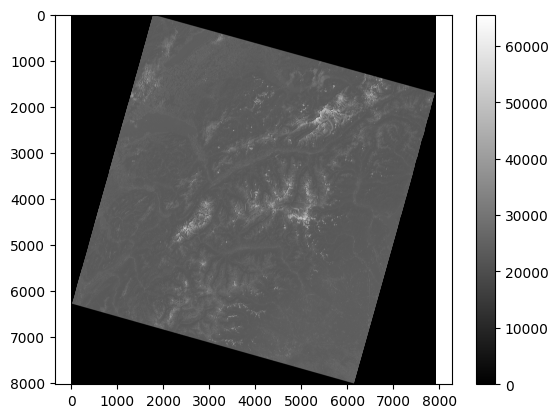

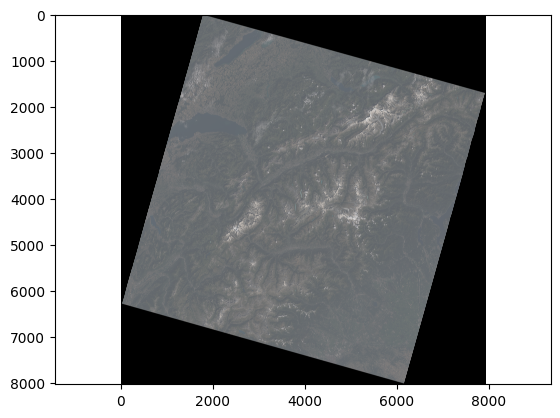

In [16]:
# Loading 4 bands
B = rasterio.open('LC08_L1TP_195028_20230820_20230826_02_T1_B2.TIF').read(1)
G = rasterio.open('LC08_L1TP_195028_20230820_20230826_02_T1_B3.TIF').read(1)
R = rasterio.open('LC08_L1TP_195028_20230820_20230826_02_T1_B4.TIF').read(1)
T = rasterio.open('LC08_L1TP_195028_20230820_20230826_02_T1_B10.TIF').read(1)

#print a figure
plt.figure()
plt.imshow(exposure.adjust_gamma(B, 0.5), cmap ='gray')
plt.colorbar()
plt.axis('equal')

#print a color figure

RGB = np.float32(np.dstack((R, G, B))) / 65535
plt.figure()
plt.imshow(exposure.adjust_gamma(RGB, 0.4))
plt.axis('equal')


In [21]:
T_doublePrecision = T.astype(np.float64) # Convert T to double precision

# Constants (replace Ml, Al, K1, K2 with actual values from metadata file)

Ml = 0.0003342 #Example value
Al = 0.1 #Example value
K1 = 774.8853 #Example value
K2 = 1321.0789 #Example value

# Calculate at-sensor radiance using gain (Ml) and offset (Al)

L_lambda = Ml * T_doublePrecision + Al

# Convert radiance to temperature in Kelvin using constants K1 and K2

T_K = K2 / (np.log((K1 / L_lambda) + 1))

# finally convert kelvin to Celsius (remember the formula?) and call the result T_C

T_C = T_K - 273.15

print(T_C)

[[-125.63290426 -125.63290426 -125.63290426 ... -125.63290426
  -125.63290426 -125.63290426]
 [-125.63290426 -125.63290426 -125.63290426 ... -125.63290426
  -125.63290426 -125.63290426]
 [-125.63290426 -125.63290426 -125.63290426 ... -125.63290426
  -125.63290426 -125.63290426]
 ...
 [-125.63290426 -125.63290426 -125.63290426 ... -125.63290426
  -125.63290426 -125.63290426]
 [-125.63290426 -125.63290426 -125.63290426 ... -125.63290426
  -125.63290426 -125.63290426]
 [-125.63290426 -125.63290426 -125.63290426 ... -125.63290426
  -125.63290426 -125.63290426]]


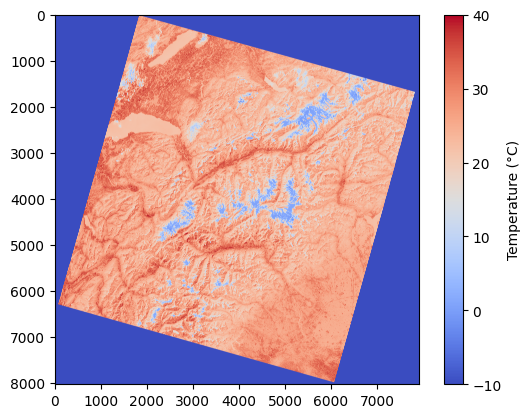

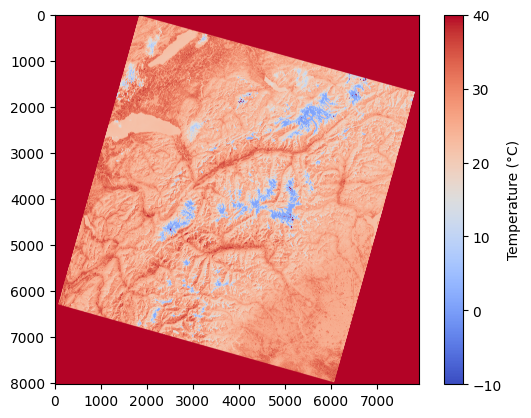

In [23]:
# Display temperature image
plt.figure(3)
plt.imshow(T_C, cmap='coolwarm', vmin = -10,vmax = 40)
plt.colorbar(label='Temperature (°C)')
plt.show()

#create a copy to visualize <0 temperatures
T_C_thr = T_C.copy()
T_C_thr[T_C_thr <= 0] = 80

plt.figure(4)
plt.imshow(T_C_thr, cmap='coolwarm', vmin = -10,vmax = 40)
plt.colorbar(label='Temperature (°C)')
plt.show()

In [25]:
# Pixels sous 0 °C ET valides (on exclut le fond noir où B10 = 0)
masque = (T_C < 0) & (T != 0)

n_pixels = np.count_nonzero(masque)

# Surface d'un pixel : 30 m x 30 m = 900 m² = 0.0009 km²
surface_pixel_km2 = (30 * 30) / 1e6

surface_km2 = n_pixels * surface_pixel_km2
print(n_pixels, "pixels ->", surface_km2, "km²")

# Pour vérifier l'ordre de grandeur : surface totale de la scène utile
surface_totale_km2 = np.count_nonzero(T != 0) * surface_pixel_km2
print("Surface totale valide :", surface_totale_km2, "km²")
print("Part sous 0 °C :", 100 * surface_km2 / surface_totale_km2, "%")

13097 pixels -> 11.7873 km²
Surface totale valide : 36582.9354 km²
Part sous 0 °C : 0.03222076050245 %
